Performance Analytics

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Load files
fund_master = pd.read_csv("01_fund_master.csv")
nav = pd.read_csv("02_nav_history.csv")
benchmark = pd.read_csv("10_benchmark_indices.csv")

In [3]:
print(nav.shape)
print(nav.columns)

nav.head()

(46000, 3)
Index(['amfi_code', 'date', 'nav'], dtype='str')


,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [4]:
nav['date'] = pd.to_datetime(nav['date'])
benchmark['date'] = pd.to_datetime(benchmark['date'])

In [5]:
nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
       .pct_change()
)

In [6]:
nav[['amfi_code','date','nav','daily_return']].head()

,amfi_code,date,nav,daily_return
0,119551,2022-01-03,54.3856,NaN
1,119551,2022-01-04,54.3474,-0.000702
2,119551,2022-01-05,54.6869,0.006247
3,119551,2022-01-06,55.4550,0.014045
4,119551,2022-01-07,55.3692,-0.001547


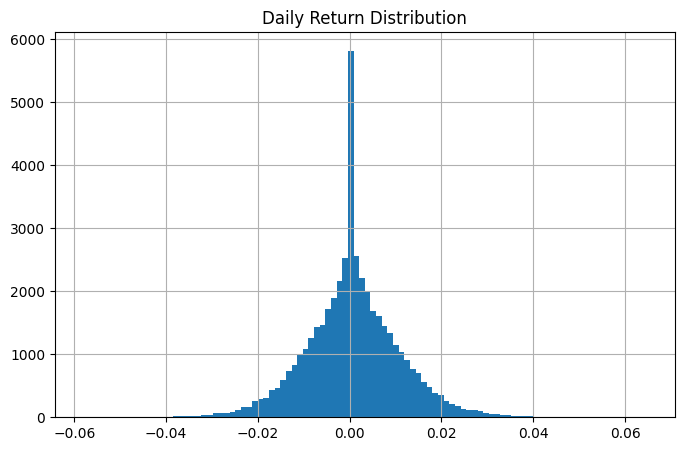

In [7]:
plt.figure(figsize=(8,5))

nav['daily_return'].hist(
    bins=100
)

plt.title("Daily Return Distribution")
plt.show()

In [1]:
def calculate_cagr(df, years):

    end_date = df['date'].max()

    start_date = end_date - pd.DateOffset(years=years)

    subset = df[df['date'] >= start_date]

    if len(subset) < 2:
        return np.nan

    start_nav = subset.iloc[0]['nav']
    end_nav = subset.iloc[-1]['nav']

    return (end_nav/start_nav)**(1/years)-1

In [17]:
rf = 0.065

In [18]:
def sharpe_ratio(returns):

    annual_return = returns.mean()*252

    annual_vol = returns.std()*np.sqrt(252)

    return (annual_return-rf)/annual_vol

In [26]:
import os

print("Current Working Directory:")
print(os.getcwd())

print("\nAll files and folders:")
for item in os.listdir():
    print(item)

Current Working Directory:
c:\Users\KIIT0001\Downloads

All files and folders:
01_fund_master.csv
02_nav_history.csv
03_aum_by_fund_house.csv
04_monthly_sip_inflows.csv
05_category_inflows.csv
06_industry_folio_count.csv
07_scheme_performance.csv
08_investor_transactions.csv
09_portfolio_holdings.csv
1.pdf
10_benchmark_indices.csv
5064485-EDA_Project.ipynb
alpha_beta.csv
Bluestock_MF_Capstone_Project.pdf
desktop.ini
fund_scorecard.csv
Git-2.54.0-64-bit.exe
Performance_Analytics.ipynb


In [27]:
import pandas as pd
import numpy as np

fund_master = pd.read_csv("01_fund_master.csv")
nav = pd.read_csv("02_nav_history.csv")
benchmark = pd.read_csv("10_benchmark_indices.csv")

In [28]:
print(nav.columns.tolist())

['amfi_code', 'date', 'nav']


In [30]:
print(nav.dtypes)

amfi_code      int64
date             str
nav          float64
dtype: object


In [31]:
nav['date'] = pd.to_datetime(nav['date'])


In [32]:
print(nav.dtypes)

amfi_code             int64
date         datetime64[us]
nav                 float64
dtype: object


In [33]:
cagr_results = []

for code, group in nav.groupby('amfi_code'):

    cagr_results.append({
        'amfi_code': code,
        'CAGR_1Y': calculate_cagr(group, 1),
        'CAGR_3Y': calculate_cagr(group, 3),
        'CAGR_5Y': calculate_cagr(group, 5)
    })

cagr_df = pd.DataFrame(cagr_results)

cagr_df.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,-0.022243,0.012926,0.023168
1,100025,0.037050,0.039164,0.039127
2,100033,0.532324,0.324425,0.260741
3,101206,0.479241,0.289677,0.204427
4,101207,-0.239860,-0.041524,0.069533


In [34]:
cagr_df = cagr_df.merge(
    fund_master[['amfi_code','scheme_name']],
    on='amfi_code'
)

In [35]:
rf = 0.065

In [36]:
def sharpe_ratio(returns):

    annual_return = returns.mean()*252

    annual_vol = returns.std()*np.sqrt(252)

    return (annual_return-rf)/annual_vol

In [ ]:
sharpe_data = []

for code, group in nav.groupby('amfi_code'):

    ret = group['daily_return'].dropna()

    sharpe_data.append({
        'amfi_code': code,
        'Sharpe': sharpe_ratio(ret)
    })

sharpe_df = pd.DataFrame(sharpe_data)

In [43]:
nav = nav.sort_values(
    ['amfi_code', 'date']
)

nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
       .pct_change()
)

In [44]:
print(nav[['amfi_code','date','nav','daily_return']].head())

      amfi_code       date       nav  daily_return
5750     100016 2022-01-03  520.4608           NaN
5751     100016 2022-01-04  515.0971     -0.010306
5752     100016 2022-01-05  521.7239      0.012865
5753     100016 2022-01-06  515.7880     -0.011377
5754     100016 2022-01-07  515.1639     -0.001210


In [45]:
print(nav.columns.tolist())

['amfi_code', 'date', 'nav', 'daily_return']


In [46]:
sharpe_data = []

for code, group in nav.groupby('amfi_code'):

    ret = group['daily_return'].dropna()

    sharpe_data.append({
        'amfi_code': code,
        'Sharpe': sharpe_ratio(ret)
    })

sharpe_df = pd.DataFrame(sharpe_data)

In [47]:
sharpe_df.sort_values(
    'Sharpe',
    ascending=False
)

,amfi_code,Sharpe
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101
38,149323,1.132122
2,100033,1.093699
9,118632,1.081659
3,101206,1.027213
24,120504,1.026524


In [48]:
def sortino_ratio(returns):

    annual_return = returns.mean()*252

    downside = returns[returns < 0]

    downside_vol = downside.std()*np.sqrt(252)

    return (annual_return-rf)/downside_vol

In [49]:
sortino_data = []

for code, group in nav.groupby('amfi_code'):

    ret = group['daily_return'].dropna()

    sortino_data.append({
        'amfi_code': code,
        'Sortino': sortino_ratio(ret)
    })

sortino_df = pd.DataFrame(sortino_data)

In [50]:
nifty100 = benchmark[
    benchmark['index_name']=="NIFTY100"
].copy()

nifty100 = nifty100.sort_values('date')

nifty100['benchmark_return'] = (
    nifty100['close_value']
    .pct_change()
)

In [51]:
alpha_beta = []

In [53]:
print(nifty100.dtypes)

date                    str
index_name              str
close_value         float64
benchmark_return    float64
dtype: object


In [54]:
benchmark['date'] = pd.to_datetime(
    benchmark['date'],
    dayfirst=True,
    errors='coerce'
)

In [55]:
nifty100 = benchmark[
    benchmark['index_name'] == 'NIFTY100'
].copy()

nifty100 = nifty100.sort_values('date')

nifty100['benchmark_return'] = (
    nifty100['close_value']
    .pct_change()
)

In [56]:
print(nav['date'].dtype)
print(nifty100['date'].dtype)

datetime64[us]
datetime64[us]


In [59]:
from scipy.stats import linregress

In [60]:
print(linregress)

<function linregress at 0x0000029A9C9B3A60>


In [62]:
alpha_beta = []

for code, group in nav.groupby('amfi_code'):

    merged = group[['date','daily_return']].merge(
        nifty100[['date','benchmark_return']],
        on='date',
        how='inner'
    ).dropna()

    if len(merged) < 30:
        continue

    slope, intercept, r, p, se = linregress(
        merged['benchmark_return'],
        merged['daily_return']
    )

    alpha_beta.append({
        'amfi_code': code,
        'Alpha': intercept * 252,
        'Beta': slope
    })

alpha_beta_df = pd.DataFrame(alpha_beta)

alpha_beta_df.head()

,amfi_code,Alpha,Beta
0,100016,-0.056783,0.003540
1,100025,0.029421,0.002139
2,100033,0.218626,-0.003239
3,101206,0.246943,0.004973
4,101207,0.009775,0.003899


In [64]:
alpha_beta_df.to_csv(
    "alpha_beta.csv",
    index=False
)

In [65]:
def max_drawdown(nav_series):

    running_max = nav_series.cummax()

    drawdown = (
        nav_series/running_max
    ) - 1

    return drawdown.min()

In [66]:
dd_results = []

for code, group in nav.groupby('amfi_code'):

    dd_results.append({
        'amfi_code': code,
        'Max_Drawdown':
        max_drawdown(group['nav'])
    })

dd_df = pd.DataFrame(dd_results)

In [71]:
group = nav[
    nav['amfi_code']==selected_fund
].copy()

group['running_max'] = group['nav'].cummax()

group['drawdown'] = (
    group['nav']/group['running_max']
)-1

worst_date = group.loc[
    group['drawdown'].idxmin(),
    'date'
]

print(worst_date)

2022-09-15 00:00:00


In [74]:
tracking = []

for code, group in nav.groupby('amfi_code'):

    merged = group[['date','daily_return']].merge(
        nifty100[['date','benchmark_return']],
        on='date'
    )

    te = (
        merged['daily_return']
        - merged['benchmark_return']
    ).std()*np.sqrt(252)

    tracking.append({
        'amfi_code':code,
        'Tracking_Error':te
    })

tracking_df = pd.DataFrame(tracking)

In [75]:
scorecard = (
    cagr_df
    .merge(sharpe_df,on='amfi_code')
    .merge(alpha_beta_df,on='amfi_code')
    .merge(dd_df,on='amfi_code')
)

In [76]:
scorecard = scorecard.merge(
    fund_master[
        ['amfi_code',
         'expense_ratio_pct']
    ],
    on='amfi_code'
)

In [77]:
scorecard['return_rank'] = (
    scorecard['CAGR_3Y']
    .rank(pct=True)
)

scorecard['sharpe_rank'] = (
    scorecard['Sharpe']
    .rank(pct=True)
)

scorecard['alpha_rank'] = (
    scorecard['Alpha']
    .rank(pct=True)
)

scorecard['expense_rank'] = (
    (1/scorecard['expense_ratio_pct'])
    .rank(pct=True)
)

scorecard['dd_rank'] = (
    (1/scorecard['Max_Drawdown'].abs())
    .rank(pct=True)
)

In [78]:
scorecard['Fund_Score'] = 100*(
      0.30*scorecard['return_rank']
    + 0.25*scorecard['sharpe_rank']
    + 0.20*scorecard['alpha_rank']
    + 0.15*scorecard['expense_rank']
    + 0.10*scorecard['dd_rank']
)

In [79]:
scorecard = scorecard.sort_values(
    'Fund_Score',
    ascending=False
)

In [80]:
scorecard.to_csv(
    "fund_scorecard.csv",
    index=False
)

In [81]:
top5 = scorecard.head(5)['amfi_code']

In [83]:
import matplotlib.pyplot as plt
print(plt)
plt.figure(figsize=(12,6))

<module 'matplotlib.pyplot' from 'C:\\Users\\KIIT0001\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python313\\site-packages\\matplotlib\\pyplot.py'>


<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

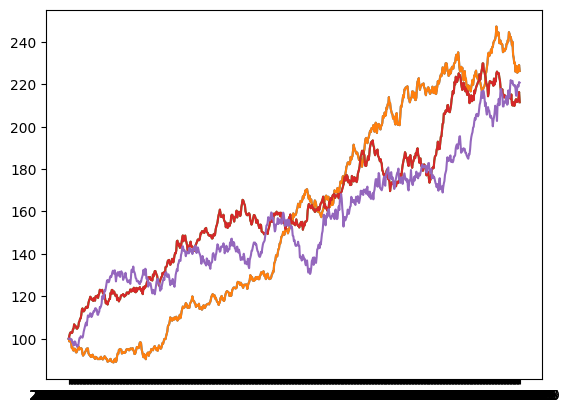

In [89]:
for code in top5:

    temp = nav[
        nav['amfi_code']==code
    ].copy()

    temp = temp.sort_values('date')

    temp = temp.tail(756)

    indexed = (
        temp['nav']
        / temp['nav'].iloc[0]
    )*100

    plt.plot(
        temp['date'],
        indexed,
        label=str(code)
    )

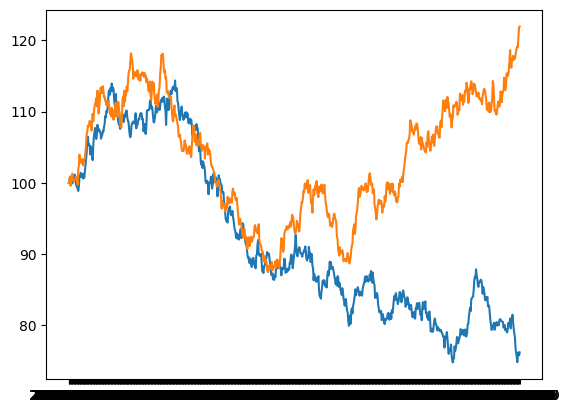

In [90]:
for idx in ['NIFTY50','NIFTY100']:

    b = benchmark[
        benchmark['index_name']==idx
    ].copy()

    b = b.tail(756)

    indexed = (
        b['close_value']
        / b['close_value'].iloc[0]
    )*100

    plt.plot(
        b['date'],
        indexed,
        label=idx
    )

C:\Users\KIIT0001\AppData\Local\Temp\ipykernel_7464\3407017864.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


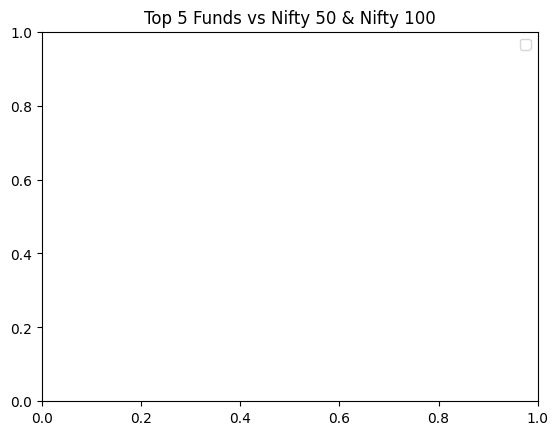

In [91]:
plt.title(
    "Top 5 Funds vs Nifty 50 & Nifty 100"
)

plt.legend()

plt.savefig(
    "benchmark_comparison_chart.png"
)

plt.show()